# Airbnb NYC Market Analysis
## Python + Pandas + NumPy + Matplotlib + Seaborn

**Dataset required:** `AB_NYC_2019.csv`

Place the CSV file in `../data/` when running this notebook locally.



In [2]:
# 1. Import libraries
import os
import warnings
warnings.filterwarnings("ignore")

import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")



In [3]:
# 2. Load dataset
DATA_PATH = "../data/AB_NYC_2019.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Download AB_NYC_2019.csv and place it inside the project's data folder."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()



Dataset loaded successfully.
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Initial Data Understanding



In [4]:
# Basic information
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include="all").T)



Rows: 48895
Columns: 16

Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,"48,895.00",NaN,NaN,NaN,"19,017,143.24","10,983,108.39","2,539.00","9,471,945.00","19,677,284.00","29,152,178.50","36,487,245.00"
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,"48,895.00",NaN,NaN,NaN,"67,620,010.65","78,610,967.03","2,438.00","7,822,033.00","30,793,816.00","107,434,423.00","274,321,313.00"
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,"48,895.00",NaN,NaN,NaN,40.73,0.05,40.50,40.69,40.72,40.76,40.91
longitude,"48,895.00",NaN,NaN,NaN,-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"48,895.00",NaN,NaN,NaN,152.72,240.15,0.00,69.00,106.00,175.00,"10,000.00"


In [5]:
# Missing values
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)
missing["missing_percent"] = missing["missing_count"] / len(df) * 100
display(missing[missing["missing_count"] > 0])



,missing_count,missing_percent
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())



Duplicate rows: 0


## 4. Data Cleaning
We will clean data carefully rather than blindly deleting records.



In [7]:
# Work on a copy
clean_df = df.copy()

# Remove exact duplicate rows
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Convert date column
clean_df["last_review"] = pd.to_datetime(clean_df["last_review"], errors="coerce")

# Reviews per month is missing mainly where there are no reviews.
# Keep the original meaning in a separate indicator, then fill for analysis.
clean_df["has_reviews"] = clean_df["number_of_reviews"].fillna(0).gt(0)
clean_df["reviews_per_month"] = clean_df["reviews_per_month"].fillna(0)

# Host name is not required for analysis; preserve host_id instead.
clean_df["host_name"] = clean_df["host_name"].fillna("Unknown")

# Listing name is useful for exploration, but missing names are rare.
clean_df["name"] = clean_df["name"].fillna("Unknown Listing")

# Basic validity filters
clean_df = clean_df[
    (clean_df["price"] >= 0) &
    (clean_df["minimum_nights"] >= 1) &
    (clean_df["availability_365"] >= 0) &
    (clean_df["availability_365"] <= 365)
].copy()

clean_df.reset_index(drop=True, inplace=True)

print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)



Original shape: (48895, 16)
Cleaned shape: (48895, 17)


In [8]:
# Check cleaned data
display(clean_df.isna().sum().sort_values(ascending=False).head(10))
display(clean_df.head())



last_review            10052
id                         0
name                       0
host_name                  0
host_id                    0
neighbourhood              0
latitude                   0
longitude                  0
neighbourhood_group        0
room_type                  0
dtype: int64

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365,True
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,True
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaT,0.00,1,365,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,True
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,True


In [9]:
# Save cleaned dataset
# OUTPUT_PATH = "../outputs/cleaned_data/airbnb_cleaned.csv"
# clean_df.to_csv(OUTPUT_PATH, index=False)
# print(f"Saved cleaned dataset to: {OUTPUT_PATH}")



## 5. Feature Engineering



In [10]:
# Create useful analysis columns
clean_df["price_per_minimum_night"] = (
    clean_df["price"] / clean_df["minimum_nights"].replace(0, np.nan)
)

clean_df["review_year"] = clean_df["last_review"].dt.year
clean_df["review_month"] = clean_df["last_review"].dt.month

# Price bands for easier segmentation
clean_df["price_band"] = pd.cut(
    clean_df["price"],
    bins=[-1, 50, 100, 200, 500, np.inf],
    labels=["$0-50", "$51-100", "$101-200", "$201-500", "$500+"]
)

clean_df[[
    "price", "minimum_nights", "number_of_reviews",
    "availability_365", "price_band"
]].head()



,price,minimum_nights,number_of_reviews,availability_365,price_band
0,149,1,9,365,$101-200
1,225,1,45,355,$201-500
2,150,3,0,365,$101-200
3,89,1,270,194,$51-100
4,80,10,9,0,$51-100


In [11]:
import csv

# 1. 'name' aur 'host_name' se newlines, tabs aur carriage returns clean karein 
clean_df["name"] = (
    clean_df["name"]
    .astype(str)
    .str.replace(r'[\r\n\t]+', ' ', regex=True)
    .str.strip()
)
clean_df["host_name"] = (
    clean_df["host_name"]
    .astype(str)
    .str.replace(r'[\r\n\t]+', ' ', regex=True)
    .str.strip()
)

# 2. Date ko standard ISO format string banayein
clean_df["last_review"] = clean_df["last_review"].dt.strftime("%Y-%m-%d")

# 3. Robust Quoting ke saath CSV export karein
OUTPUT_PATH = "../outputs/cleaned_data/airbnb_cleaned.csv"

clean_df.to_csv(
    OUTPUT_PATH,
    index=False,
    quoting=csv.QUOTE_NONNUMERIC,   # Sabhi string/text columns quotes (" ") ke andar aayenge
    quotechar='"',
    escapechar='\\',                # Quotes ke andar ke special characters escape ho jayenge
    encoding="utf-8"
)

print(f"Cleaned dataset safely exported with shape {clean_df.shape} to: {OUTPUT_PATH}")

Cleaned dataset safely exported with shape (48895, 21) to: ../outputs/cleaned_data/airbnb_cleaned.csv


## 6. Exploratory Data Analysis — Listings by Borough



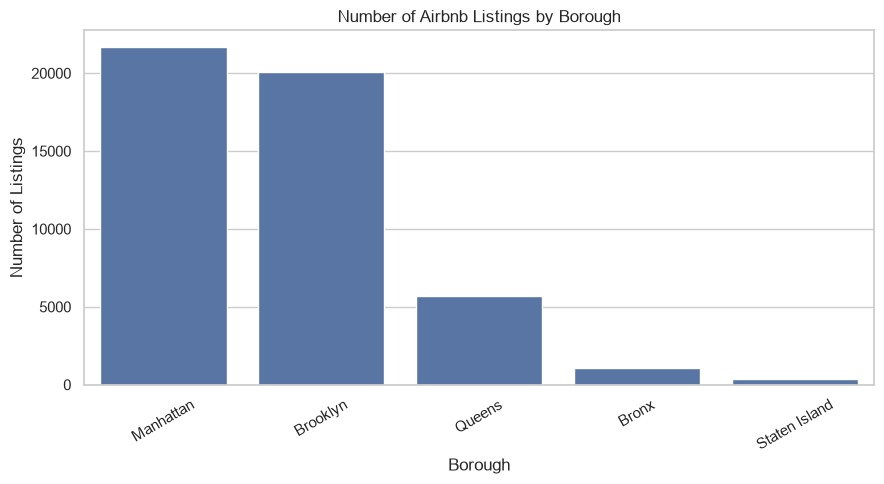

In [12]:
borough_counts = clean_df["neighbourhood_group"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=borough_counts.index, y=borough_counts.values)
plt.title("Number of Airbnb Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/charts/listings_by_borough.png", dpi=200)
plt.show()



## 7. Room Type Analysis



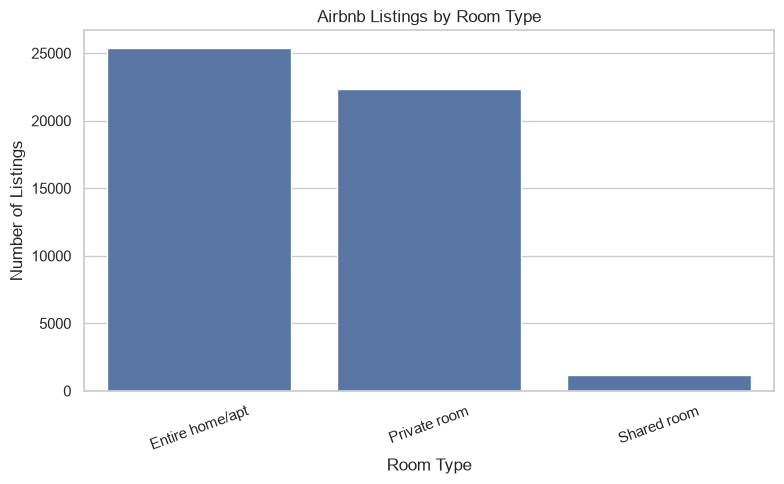

,percentage
room_type,
Entire home/apt,51.97
Private room,45.66
Shared room,2.37


In [13]:
room_counts = clean_df["room_type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=room_counts.index, y=room_counts.values)
plt.title("Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/charts/room_type_distribution.png", dpi=200)
plt.show()

display(
    clean_df["room_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)



## 8. Average Price by Borough



,neighbourhood_group,price
2,Manhattan,196.88
1,Brooklyn,124.38
4,Staten Island,114.81
3,Queens,99.52
0,Bronx,87.50


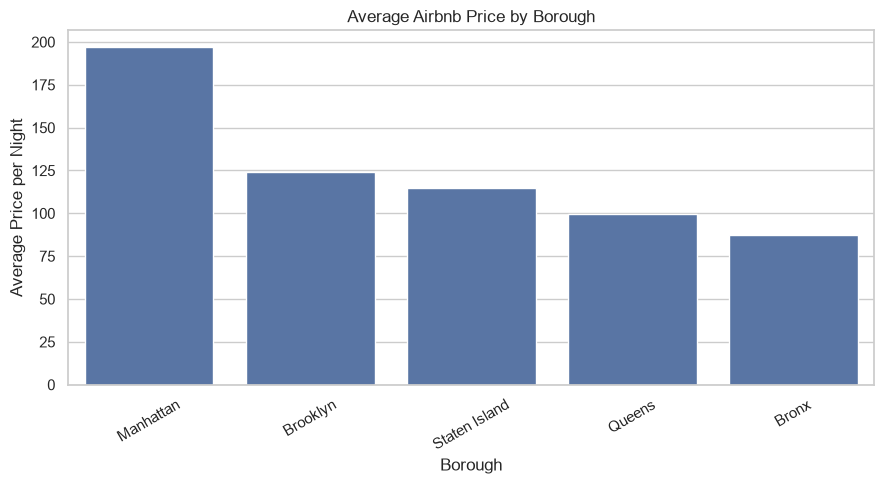

In [14]:
avg_price_borough = (
    clean_df.groupby("neighbourhood_group", as_index=False)["price"]
    .mean()
    .sort_values("price", ascending=False)
)

display(avg_price_borough)

plt.figure(figsize=(9, 5))
sns.barplot(data=avg_price_borough, x="neighbourhood_group", y="price")
plt.title("Average Airbnb Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price per Night")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/charts/average_price_by_borough.png", dpi=200)
plt.show()



## 9. Median Price by Borough and Room Type
Mean price can be affected by outliers, so median is also useful.



,neighbourhood_group,room_type,price
6,Manhattan,Entire home/apt,191.00
3,Brooklyn,Entire home/apt,145.00
9,Queens,Entire home/apt,120.00
12,Staten Island,Entire home/apt,100.00
0,Bronx,Entire home/apt,100.00
7,Manhattan,Private room,90.00
8,Manhattan,Shared room,69.00
4,Brooklyn,Private room,65.00
10,Queens,Private room,60.00
1,Bronx,Private room,53.50


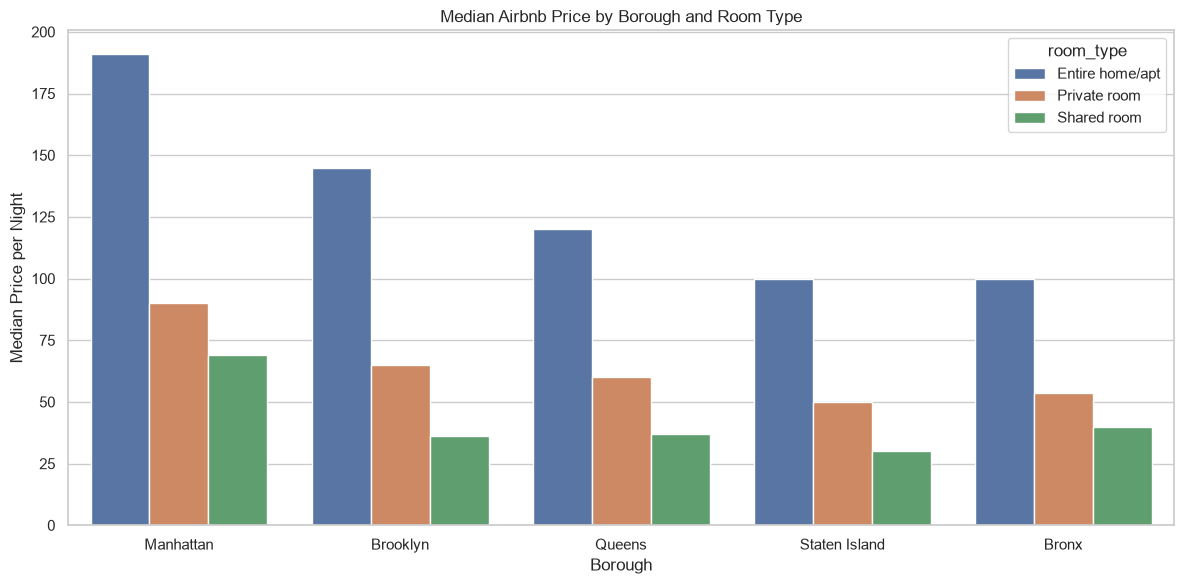

In [15]:
median_price = (
    clean_df.groupby(["neighbourhood_group", "room_type"], as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

display(median_price)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=median_price,
    x="neighbourhood_group",
    y="price",
    hue="room_type"
)
plt.title("Median Airbnb Price by Borough and Room Type")
plt.xlabel("Borough")
plt.ylabel("Median Price per Night")
plt.tight_layout()
plt.savefig("../outputs/charts/median_price_borough_room_type.png", dpi=200)
plt.show()



## 10. Neighborhood Analysis



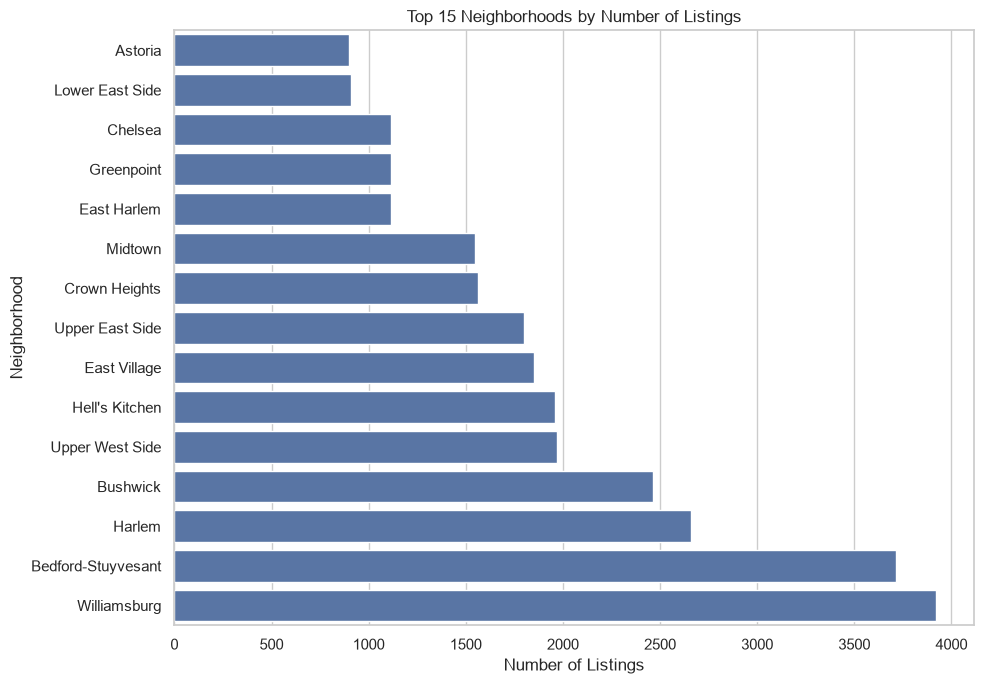

In [16]:
top_neighbourhoods = (
    clean_df["neighbourhood"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index)
plt.title("Top 15 Neighborhoods by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.savefig("../outputs/charts/top_neighbourhoods.png", dpi=200)
plt.show()



In [17]:
top_expensive_neighbourhoods = (
    clean_df.groupby("neighbourhood")
    .agg(
        listings=("id", "count"),
        median_price=("price", "median"),
        average_price=("price", "mean")
    )
    .query("listings >= 50")
    .sort_values("median_price", ascending=False)
    .head(15)
)

display(top_expensive_neighbourhoods)



,listings,median_price,average_price
neighbourhood,,,
Tribeca,177,295.00,490.64
NoHo,78,250.00,295.72
Flatiron District,80,225.00,341.93
Midtown,1545,210.00,282.72
Financial District,744,200.00,225.49
West Village,768,200.00,267.68
SoHo,358,199.00,287.10
Chelsea,1113,199.00,249.74
Greenwich Village,392,197.50,263.41


## 11. Price Distribution and Outliers



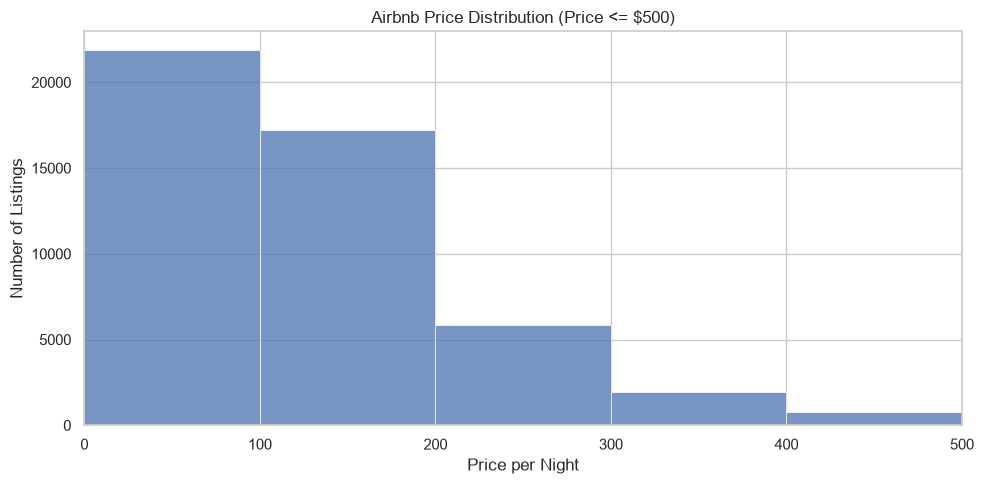

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df["price"], bins=100)
plt.xlim(0, 500)
plt.title("Airbnb Price Distribution (Price <= $500)")
plt.xlabel("Price per Night")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig("../outputs/charts/price_distribution.png", dpi=200)
plt.show()



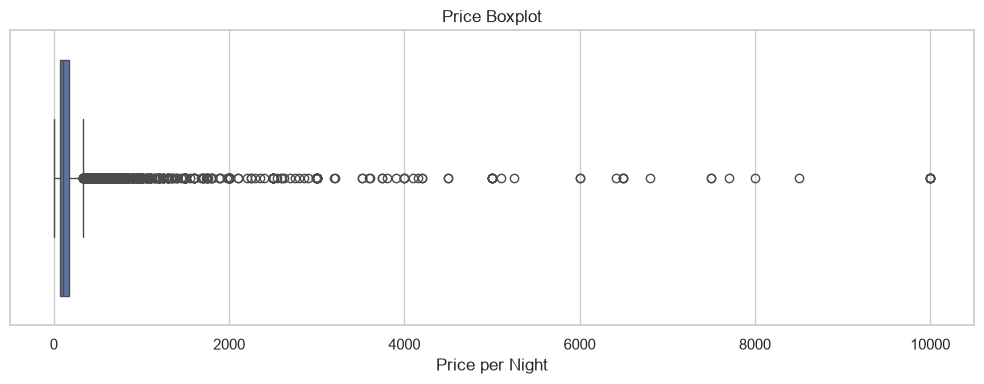

,id,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights
9151,7003697,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000,100
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000,5
29238,22436899,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000,30
6530,4737930,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999,5
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999,99
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999,30
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500,30
4377,2953058,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000,1
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703,1
42523,33007610,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500,1


In [19]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=clean_df["price"])
plt.title("Price Boxplot")
plt.xlabel("Price per Night")
plt.tight_layout()
plt.savefig("../outputs/charts/price_boxplot.png", dpi=200)
plt.show()

display(clean_df.nlargest(10, "price")[[
    "id", "name", "neighbourhood_group", "neighbourhood",
    "room_type", "price", "minimum_nights"
]])



## 12. Reviews Analysis



In [20]:
review_summary = clean_df[[
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]].describe().T

display(review_summary)



,count,mean,std,min,25%,50%,75%,max
number_of_reviews,"48,895.00",23.27,44.55,0.00,1.00,5.00,24.00,629.00
reviews_per_month,"48,895.00",1.09,1.60,0.00,0.04,0.37,1.58,58.50
availability_365,"48,895.00",112.78,131.62,0.00,0.00,45.00,227.00,365.00


In [21]:
# Listings with the highest number of reviews
most_reviewed = clean_df.nlargest(15, "number_of_reviews")[[
    "id", "name", "neighbourhood_group",
    "room_type", "price", "number_of_reviews"
]]

display(most_reviewed)



,id,name,neighbourhood_group,room_type,price,number_of_reviews
11759,9145202,Room near JFK Queen Bed,Queens,Private room,47,629
2031,903972,Great Bedroom in Manhattan,Manhattan,Private room,49,607
2030,903947,Beautiful Bedroom in Manhattan,Manhattan,Private room,49,597
2015,891117,Private Bedroom in Manhattan,Manhattan,Private room,49,594
13495,10101135,Room Near JFK Twin Beds,Queens,Private room,47,576
10623,8168619,Steps away from Laguardia airport,Queens,Private room,46,543
1879,834190,Manhattan Lux Loft.Like.Love.Lots.Look !,Manhattan,Private room,99,540
20403,16276632,Cozy Room Family Home LGA Airport NO CLEANING FEE,Queens,Private room,48,510
4870,3474320,Private brownstone studio Brooklyn,Brooklyn,Entire home/apt,160,488
471,166172,LG Private Room/Family Friendly,Brooklyn,Private room,60,480


## 13. Price vs Number of Reviews



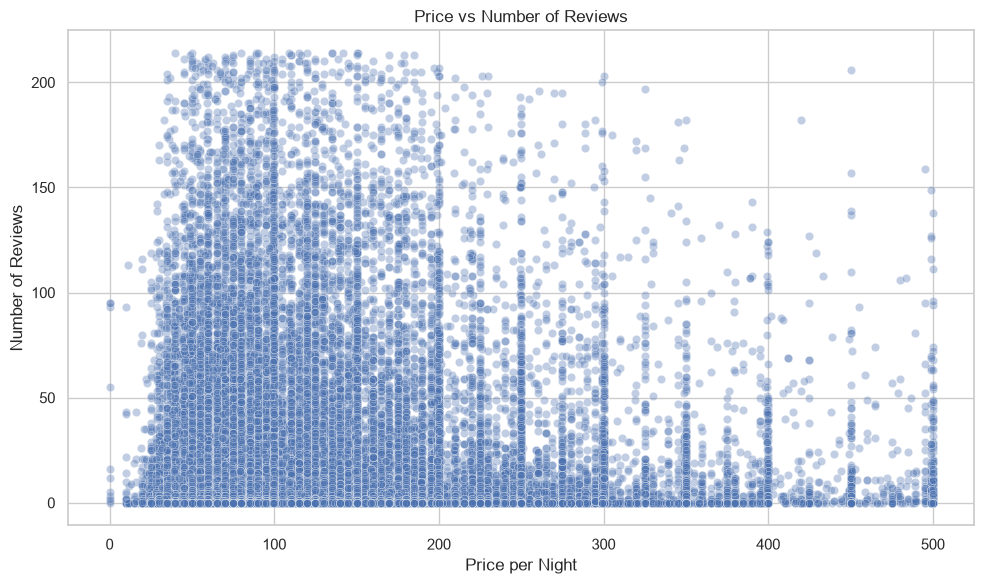

,price,number_of_reviews,reviews_per_month
price,1.00,-0.05,-0.05
number_of_reviews,-0.05,1.00,0.59
reviews_per_month,-0.05,0.59,1.00


In [22]:
plot_df = clean_df[
    (clean_df["price"] <= 500) &
    (clean_df["number_of_reviews"] <= clean_df["number_of_reviews"].quantile(0.99))
]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="price",
    y="number_of_reviews",
    alpha=0.35
)
plt.title("Price vs Number of Reviews")
plt.xlabel("Price per Night")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("../outputs/charts/price_vs_reviews.png", dpi=200)
plt.show()

display(
    clean_df[["price", "number_of_reviews", "reviews_per_month"]]
    .corr(numeric_only=True)
)



## 14. Host Analysis



In [23]:
host_summary = (
    clean_df.groupby("host_id")
    .agg(
        listings=("id", "count"),
        total_reviews=("number_of_reviews", "sum"),
        average_price=("price", "mean"),
        average_availability=("availability_365", "mean")
    )
    .sort_values("listings", ascending=False)
)

display(host_summary.head(15))



,listings,total_reviews,average_price,average_availability
host_id,,,,
219517861,327,1281,253.20,301.49
107434423,232,29,303.15,253.81
30283594,121,65,277.53,313.42
137358866,103,87,43.83,196.48
12243051,96,43,213.03,276.61
16098958,96,138,208.96,292.32
61391963,91,417,146.24,241.92
22541573,87,55,215.44,312.17
200380610,65,1,290.23,338.03


## 15. Geographic Distribution



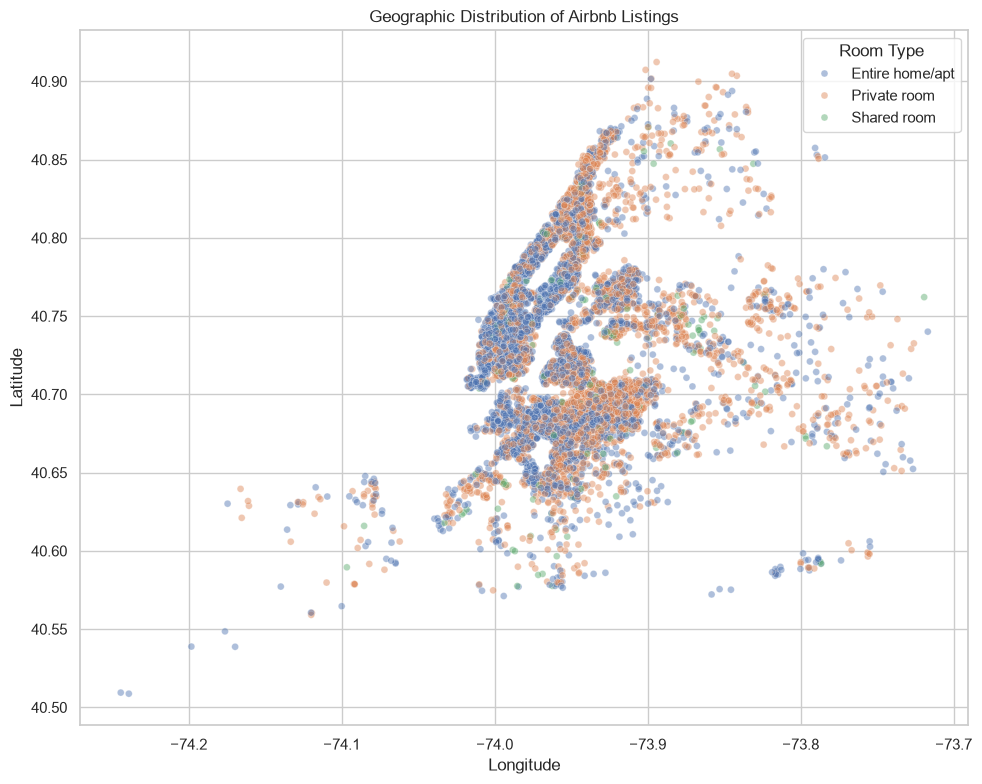

In [24]:
# Sample for faster plotting
geo_df = clean_df.sample(
    n=min(10000, len(clean_df)),
    random_state=42
)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=geo_df,
    x="longitude",
    y="latitude",
    hue="room_type",
    alpha=0.45,
    s=25
)
plt.title("Geographic Distribution of Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Room Type")
plt.tight_layout()
plt.savefig("../outputs/charts/geographic_distribution.png", dpi=200)
plt.show()



## 16. Availability Analysis



,room_type,availability_365
2,Shared room,90.00
1,Private room,45.00
0,Entire home/apt,42.00


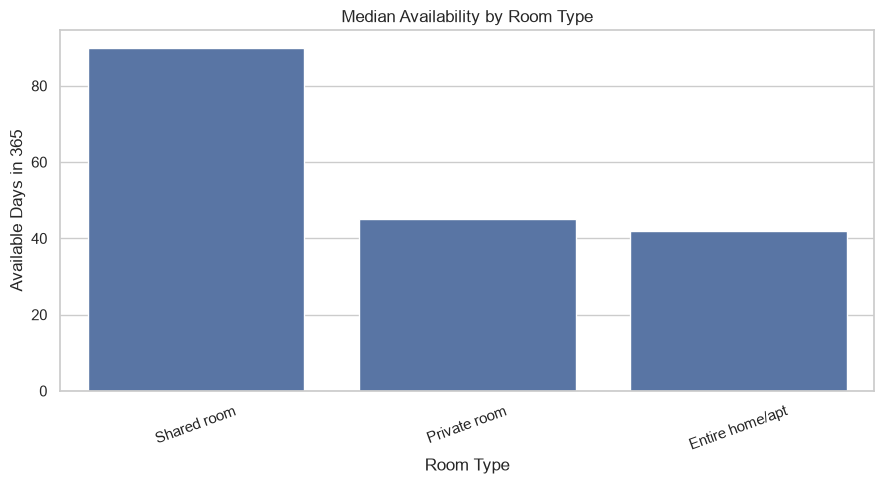

In [25]:
availability_by_room = (
    clean_df.groupby("room_type", as_index=False)["availability_365"]
    .median()
    .sort_values("availability_365", ascending=False)
)

display(availability_by_room)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=availability_by_room,
    x="room_type",
    y="availability_365"
)
plt.title("Median Availability by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Available Days in 365")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/charts/availability_by_room_type.png", dpi=200)
plt.show()



## 17. Minimum Nights Analysis



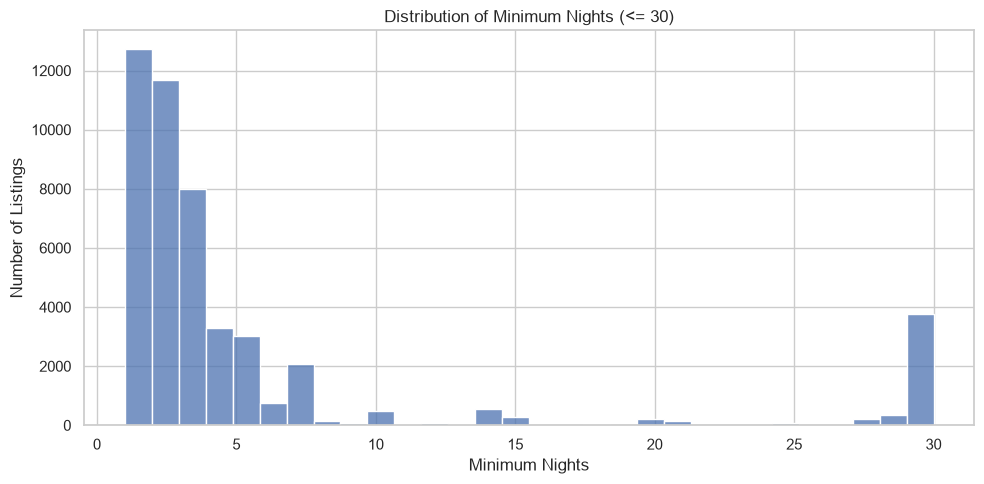

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(
    clean_df.loc[clean_df["minimum_nights"] <= 30, "minimum_nights"],
    bins=30
)
plt.title("Distribution of Minimum Nights (<= 30)")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig("../outputs/charts/minimum_nights.png", dpi=200)
plt.show()



## 18. Key KPI Table



In [27]:
kpis = {
    "Total Listings": len(clean_df),
    "Unique Hosts": clean_df["host_id"].nunique(),
    "Unique Neighborhoods": clean_df["neighbourhood"].nunique(),
    "Average Price": clean_df["price"].mean(),
    "Median Price": clean_df["price"].median(),
    "Average Reviews": clean_df["number_of_reviews"].mean(),
    "Median Availability": clean_df["availability_365"].median()
}

kpi_df = pd.DataFrame(
    {"KPI": list(kpis.keys()), "Value": list(kpis.values())}
)

display(kpi_df)



,KPI,Value
0,Total Listings,"48,895.00"
1,Unique Hosts,"37,457.00"
2,Unique Neighborhoods,221.00
3,Average Price,152.72
4,Median Price,106.00
5,Average Reviews,23.27
6,Median Availability,45.00


## 19. Export Tables for Power BI



In [28]:
# Export useful analytical tables
avg_price_borough.to_csv(
    "../outputs/cleaned_data/avg_price_by_borough.csv", index=False
)

median_price.to_csv(
    "../outputs/cleaned_data/median_price_by_borough_room_type.csv",
    index=False
)

host_summary.reset_index().to_csv(
    "../outputs/cleaned_data/host_summary.csv",
    index=False
)

print("Power BI-ready tables exported.")



Power BI-ready tables exported.


# Conclusion
Use the charts and KPI tables above to write your own business findings.

**Important:** Do not claim that correlation proves causation, and do not call `availability_365` an actual occupancy rate. The dataset provides availability, not booked nights.

